# 01 – Explore: EDA & Data Quality Assessment

**Course:** DLBDSDQDW01 – Data Quality and Data Wrangling (IU Internationale Hochschule)
**Dataset:** MIMIC-IV v3.1 (Johnson et al., 2023)

---

## Objective

Systematically assess MIMIC-IV data quality using all six canonical dimensions from **Kahn et al. (2016)**:
Completeness, Consistency, Accuracy, Uniqueness, Validity, Timeliness.
Primary focus: `labevents` — the richest quantitative clinical signal source.

## Clinical Context

Lab ordering in the ICU is *not random*: sicker patients receive more targeted testing.
A patient who never had a lactate drawn was likely judged stable — their missingness carries
information (**MNAR by clinical design**). Sharafoddini et al. (2019) confirmed this:
83.3% lactate missing in stable vs. 7.4% in deteriorating patients.

## Target Schema: CLIF

Wrangling is framed as transforming MIMIC-IV toward the **Common Longitudinal ICU Format (CLIF)** —
a federated standard used by 17 institutions / 62 hospitals / 800 000+ patients
(Bhakti et al., *Intensive Care Medicine* 2025). The official `clif_labs` schema is previewed below.

## References

| Citation | Key role |
|----------|----------|
| Kahn et al. (2016) *eGEMS* | Canonical DQ framework (6 dimensions) |
| Johnson et al. (2023) *Sci Data* | MIMIC-IV dataset paper |
| Sharafoddini et al. (2019) *JMIR Med Inform* | ICU missingness is MNAR |
| Bhakti et al. (2025) *Intensive Care Med* | CLIF target schema |


In [1]:
from pathlib import Path
import warnings, re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (13, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
})
sns.set_style("whitegrid")

BASE     = Path("physionet.org/files/mimiciv/3.1")
HOSP     = BASE / "hosp"
ICU      = BASE / "icu"
CLIF_DIR = Path("physionet.org/files/mimic-iv-ext-clif/1.1.0")

print("Environment ready.")


Environment ready.


---
## 1. Load Core Tables

| Table | Schema | Content |
|-------|--------|---------|
| `admissions` | hosp | Hospital admissions (~546 k rows) |
| `patients` | hosp | Demographics: anchor_age, gender, dod (~365 k rows) |
| `d_labitems` | hosp | Lab item dictionary: itemid → label, fluid, category |
| `icustays` | icu | ICU-level stays: careunit, intime/outtime, LOS |


In [2]:
admissions = pd.read_csv(
    HOSP / "admissions.csv",
    parse_dates=["admittime", "dischtime", "deathtime", "edregtime", "edouttime"],
)
# patients.csv.gz has trailing garbage from wget; use zcat which tolerates it
import subprocess as _sp, io as _io
_r = _sp.run(["zcat", str(HOSP / "patients.csv.gz")], capture_output=True)
patients = pd.read_csv(_io.BytesIO(_r.stdout), parse_dates=["dod"])
d_labitems = pd.read_csv(HOSP / "d_labitems.csv")
icustays = pd.read_csv(ICU / "icustays.csv.gz", parse_dates=["intime", "outtime"])

for name, df in [("admissions", admissions), ("patients", patients),
                 ("d_labitems", d_labitems), ("icustays", icustays)]:
    print(f"{name:<12}: {df.shape[0]:>7,} rows x {df.shape[1]} cols")


admissions  : 546,028 rows x 16 cols
patients    : 364,627 rows x 6 cols
d_labitems  :   1,650 rows x 4 cols
icustays    :  94,458 rows x 8 cols


In [3]:
display(admissions.head(3))
display(icustays.head(3))

icu_mort = admissions.loc[
    admissions["hadm_id"].isin(icustays["hadm_id"]), "hospital_expire_flag"
].mean()

print(f"Unique patients         : {patients['subject_id'].nunique():,}")
print(f"Hospital admissions     : {admissions.shape[0]:,}")
print(f"ICU stays               : {icustays.shape[0]:,}")
print(f"Patients with >=1 ICU  : {icustays['subject_id'].nunique():,}")
print(f"ICU hospital mortality  : {icu_mort*100:.1f}%")
print()
print("ICU care units:")
print(icustays["first_careunit"].value_counts().to_string())


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaT,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaT,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.498


Unique patients         : 364,627
Hospital admissions     : 546,028
ICU stays               : 94,458
Patients with >=1 ICU  : 65,366
ICU hospital mortality  : 11.1%

ICU care units:
first_careunit
Medical Intensive Care Unit (MICU)                  20703
Medical/Surgical Intensive Care Unit (MICU/SICU)    15449
Cardiac Vascular Intensive Care Unit (CVICU)        14771
Surgical Intensive Care Unit (SICU)                 13009
Coronary Care Unit (CCU)                            10775
Trauma SICU (TSICU)                                 10474
Neuro Intermediate                                   5776
Neuro Surgical Intensive Care Unit (Neuro SICU)      1751
Neuro Stepdown                                       1421
Surgery/Vascular/Intermediate                         145
PACU                                                  122
Intensive Care Unit (ICU)                              33
Medicine                                               16
Surgery/Trauma                                   

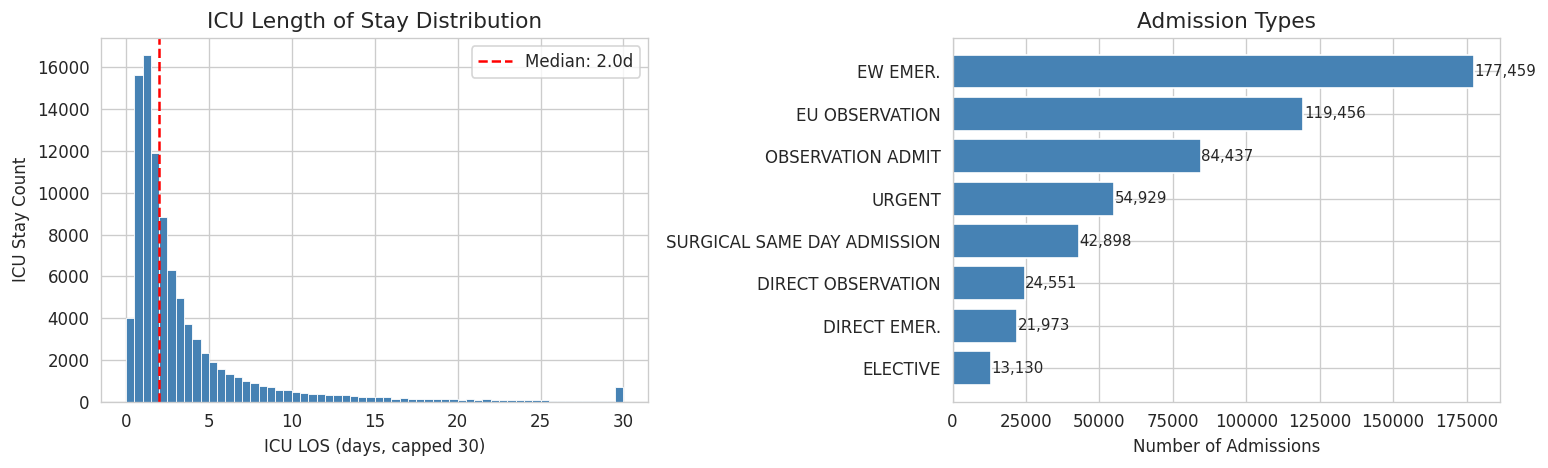

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

los = icustays["los"].clip(upper=30)
axes[0].hist(los, bins=60, color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].axvline(los.median(), color="red", linestyle="--",
                label=f"Median: {los.median():.1f}d")
axes[0].set(xlabel="ICU LOS (days, capped 30)", ylabel="ICU Stay Count",
            title="ICU Length of Stay Distribution")
axes[0].legend()

adm_types = admissions["admission_type"].value_counts().head(8)
axes[1].barh(adm_types.index[::-1], adm_types.values[::-1], color="steelblue")
axes[1].set(xlabel="Number of Admissions", title="Admission Types")
for i, v in enumerate(adm_types.values[::-1]):
    axes[1].text(v + 200, i, f"{v:,}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


---
## 2. Identify Target Lab Items

We search `d_labitems` for canonical `itemid` values for each target lab.
MIMIC stores all lab results by numeric `itemid` — correct mapping is mandatory before filtering.

| Group | Labs |
|-------|------|
| Arterial blood gas | pH, PaO2, PaCO2, HCO3, Base Excess |
| Metabolic | Lactate, Glucose, Bicarbonate |
| Electrolytes | Sodium, Potassium, Chloride, Magnesium, Calcium |
| Renal | Creatinine, BUN |
| Liver | Bilirubin total, ALT, AST |
| CBC | WBC, Hemoglobin, Hematocrit, Platelets |
| Coagulation | INR, PTT |

> **Note:** SpO2, HR, BP, FiO2 live in `chartevents` — not `labevents`.


In [5]:
LAB_SEARCH = {
    "pH":          "ph",
    "PaO2":        "po2",
    "PaCO2":       "pco2",
    # HCO3 is functionally captured by "Bicarbonate" (same measurement, different label in MIMIC)
    "Base Excess": "base excess",
    "Lactate":     "lactate",
    "Glucose":     "glucose",
    "Bicarbonate": "bicarbonate",
    "Sodium":      "sodium",
    "Potassium":   "potassium",   # NOTE: first-match maps to itemid 50833 (non-Chemistry fluid)
    "Chloride":    "chloride",
    "Magnesium":   "magnesium",
    "Calcium":     "calcium, total",
    "Creatinine":  "creatinine",
    "BUN":         "urea nitrogen",
    "Bilirubin":   "bilirubin, total",
    "ALT":         "alanine aminotransferase",   # NOTE: first-match maps to itemid 53084 (≈9 records only)
    # AST not reliably searchable by "aspartate aminotransferase" alone in MIMIC-IV v3.1
    "WBC":         "white blood cells",
    "Hemoglobin":  "hemoglobin",
    "Hematocrit":  "hematocrit",
    "Platelets":   "platelet count",
    "INR":         "inr(pt)",
    "PTT":         "ptt",
}

d_labitems["label_lower"] = d_labitems["label"].str.lower()

CANONICAL_IDS = {}
print(f"{'Lab':<16} {'itemid':>8}  {'Label':<48}  {'Fluid':<12}  Category")
print("-" * 100)

for lab, term in LAB_SEARCH.items():
    hits = d_labitems[d_labitems["label_lower"] == term.lower()]
    if hits.empty:
        hits = d_labitems[d_labitems["label_lower"].str.contains(term.lower(), na=False)]
    if not hits.empty:
        row = hits.iloc[0]
        CANONICAL_IDS[lab] = row["itemid"]
        print(f"{lab:<16} {int(row['itemid']):>8}  {row['label']:<48}  {row['fluid']:<12}  {row['category']}")
    else:
        print(f"{lab:<16} {'NOT FOUND':>8}")

ITEMID_TO_NAME = {v: k for k, v in CANONICAL_IDS.items()}
print(f"\nTarget items identified: {len(CANONICAL_IDS)}")


Lab                itemid  Label                                             Fluid         Category
----------------------------------------------------------------------------------------------------
pH                  50820  pH                                                Blood         Blood Gas
PaO2                50821  pO2                                               Blood         Blood Gas
PaCO2               50818  pCO2                                              Blood         Blood Gas
HCO3             NOT FOUND
Base Excess         50802  Base Excess                                       Blood         Blood Gas
Lactate             50813  Lactate                                           Blood         Blood Gas
Glucose             50809  Glucose                                           Blood         Blood Gas
Bicarbonate         50882  Bicarbonate                                       Blood         Chemistry
Sodium              50983  Sodium                                

### Load labevents — Chunked & Filtered

`labevents.csv.gz` is ~2 GB compressed. We stream in 500 000-row chunks and keep only target itemids.
This gives a complete (unsampled) view of quality issues for all 24 target labs.

> **Runtime:** ~3–6 min (single-threaded gzip decompression).


In [6]:
TARGET_IDS = set(CANONICAL_IDS.values())
ICU_SIDS   = set(icustays["subject_id"])

# "value" (free-text string) is loaded separately in the DQ5 cell to save RAM
LABEVENTS_COLS = [
    "subject_id", "hadm_id", "itemid",
    "charttime", "valuenum", "valueuom", "flag",
]

import subprocess as _sp
_proc = _sp.Popen(
    ["zcat", str(HOSP / "labevents.csv.gz")],
    stdout=_sp.PIPE, stderr=_sp.DEVNULL,
)

chunks, n_total = [], 0
for chunk in pd.read_csv(
    _proc.stdout,
    usecols=LABEVENTS_COLS,
    parse_dates=["charttime"],
    chunksize=500_000,
    low_memory=False,
    on_bad_lines="skip",
):
    n_total += len(chunk)
    chunk["itemid"]     = pd.to_numeric(chunk["itemid"],     errors="coerce")
    chunk["subject_id"] = pd.to_numeric(chunk["subject_id"], errors="coerce")
    filtered = chunk[
        chunk["itemid"].isin(TARGET_IDS) &
        chunk["subject_id"].isin(ICU_SIDS)
    ].copy()
    if not filtered.empty:
        chunks.append(filtered)

_proc.wait()
labs = pd.concat(chunks, ignore_index=True)

# Coerce charttime — garbled rows may have left strings instead of Timestamps
labs["charttime"] = pd.to_datetime(labs["charttime"], errors="coerce")
labs = labs.dropna(subset=["charttime"])  # drop garbled rows
labs["valuenum"] = pd.to_numeric(labs["valuenum"], errors="coerce")
labs["hadm_id"]  = pd.to_numeric(labs["hadm_id"],  errors="coerce")

labs["subject_id"] = labs["subject_id"].astype("int32")
labs["itemid"]     = labs["itemid"].astype("int32")
labs["valueuom"]   = labs["valueuom"].astype("category")
labs["flag"]       = labs["flag"].astype("category")
labs["lab_name"]   = labs["itemid"].map(ITEMID_TO_NAME).astype("category")

print(f"Total labevents rows scanned : {n_total:,}")
print(f"Target lab rows (ICU pts)    : {len(labs):,}")
print(f"Unique lab types             : {labs['lab_name'].nunique()}")
print(f"Unique ICU patients          : {labs['subject_id'].nunique():,}")
print(f"Memory usage                 : {labs.memory_usage(deep=True).sum() / 1e6:.0f} MB")
print(f"Date range: {labs['charttime'].min().date()} -> {labs['charttime'].max().date()}")
display(labs.head(4))


Total labevents rows scanned : 133,755,111
Target lab rows (ICU pts)    : 24,103,142
Unique lab types             : 21
Unique ICU patients          : 55,322
Memory usage                 : 844 MB
Date range: 2105-01-19 -> 2215-01-12


,subject_id,hadm_id,itemid,charttime,valuenum,valueuom,flag,lab_name
0,10000032,NaN,50882,2180-03-23 11:51:00,27.000,mEq/L,NaN,Bicarbonate
1,10000032,NaN,50885,2180-03-23 11:51:00,1.600,mg/dL,abnormal,Bilirubin
2,10000032,NaN,50893,2180-03-23 11:51:00,8.400,mg/dL,NaN,Calcium
3,10000032,NaN,50902,2180-03-23 11:51:00,101.000,mEq/L,NaN,Chloride


---
## 3. Target Schema: CLIF Reference

Preview the official CLIF `clif_labs` table to understand the transformation target.
CLIF requires a **single canonical unit** per `lab_name` (`reference_unit`) and
standardised `lab_category` values — so unit inconsistencies are *blocking* issues.


In [7]:
clif = pd.read_parquet(CLIF_DIR / "clif_labs.parquet")

print(f"Shape: {clif.shape[0]:,} rows x {clif.shape[1]} cols")
print("\nSchema:")
print(clif.dtypes.to_string())
print("\nSample rows:")
display(clif.head(5))

print(f"\nUnique lab_name values: {clif['lab_name'].nunique()}")
print("\nCanonical reference_unit per lab_name (sample):")
print(clif.groupby("lab_name")["reference_unit"].first().to_string())

del clif  # free memory


Shape: 48,386,986 rows x 14 cols

Schema:
hospitalization_id                       str
lab_order_dttm           datetime64[us, UTC]
lab_collect_dttm         datetime64[us, UTC]
lab_result_dttm          datetime64[us, UTC]
lab_order_name                        object
lab_order_category                       str
lab_name                                 str
lab_category                             str
lab_value                                str
lab_value_numeric                    float64
reference_unit                           str
lab_specimen_name                     object
lab_specimen_category                 object
lab_loinc_code                        object

Sample rows:


,hospitalization_id,lab_order_dttm,lab_collect_dttm,lab_result_dttm,lab_order_name,lab_order_category,lab_name,lab_category,lab_value,lab_value_numeric,reference_unit,lab_specimen_name,lab_specimen_category,lab_loinc_code
0,20000019,2159-03-21 11:45:00+00:00,2159-03-21 11:45:00+00:00,2159-03-21 13:43:00+00:00,None,cbc,Hemoglobin,hemoglobin,9.2,9.200,g/dL,None,None,None
1,20000019,2159-03-21 11:45:00+00:00,2159-03-21 11:45:00+00:00,2159-03-21 13:43:00+00:00,None,cbc,Platelet Count,platelet_count,183,183.000,10*3/uL,None,None,None
2,20000019,2159-03-21 11:45:00+00:00,2159-03-21 11:45:00+00:00,2159-03-21 13:43:00+00:00,None,cbc,White Blood Cells,wbc,15.7,15.700,10*3/uL,None,None,None
3,20000019,2159-03-21 11:45:00+00:00,2159-03-21 11:45:00+00:00,2159-03-21 13:54:00+00:00,None,bmp,Bicarbonate,bicarbonate,24.0,24.000,mmol/L,None,None,None
4,20000019,2159-03-21 11:45:00+00:00,2159-03-21 11:45:00+00:00,2159-03-21 13:54:00+00:00,None,bmp,Urea Nitrogen,bun,19,19.000,mg/dL,None,None,None



Unique lab_name values: 64

Canonical reference_unit per lab_name (sample):
lab_name
Absolute Basophil Count              10^3/µL
Absolute Eosinophil Count            10^3/µL
Absolute Lymphocyte Count          10^3/µL\t
Absolute Monocyte Count              10^3/µL
Absolute Neutrophil Count            10^3/µL
Alanine Aminotransferase (ALT)           U/L
Albumin                                 g/dL
Alkaline Phosphatase                     U/L
Arterial CO2 Pressure                   mmHg
Arterial O2 Saturation                     %
Arterial O2 pressure                    mmHg
Asparate Aminotransferase (AST)          U/L
Basophils                                  %
Bicarbonate                           mmol/L
Bilirubin, Direct                      mg/dL
Bilirubin, Indirect                    mg/dL
Bilirubin, Total                       mg/dL
C-Reactive Protein                      mg/L
Calcium, Total                         mg/dL
Central Venous O2% Sat                     %
Chloride      

---
## 4. Data Quality Analysis — Six Dimensions (Kahn 2016)

| # | Dimension | Definition | Key MIMIC-IV Issue |
|---|-----------|------------|--------------------|
| 1 | **Completeness** | Required values are present | >60% missing for many labs; MNAR structure |
| 2 | **Consistency** | Values uniform across records | Same lab in multiple units (creatinine mg/dL vs µmol/L) |
| 3 | **Accuracy** | Values reflect reality | Physiologically impossible entries |
| 4 | **Uniqueness** | No duplicate records | Same patient × lab × timestamp recorded twice |
| 5 | **Validity** | Values conform to expected format | Free text in numeric fields; range-censored strings |
| 6 | **Timeliness** | Data available within expected time window | Irregular sampling; gaps > 24h |


### 4.1 DQ1 — Completeness

**Column-level:** Which fields have null values in `admissions` and `labevents`?
**Patient-level coverage:** What fraction of ICU patients ever had each lab measured?

> Sharafoddini et al. (2019): lactate missing in **83.3%** of stable vs **7.4%** of deteriorating patients.
> This confirms MNAR structure — not random, not a data quality failure, but clinical decision-making.


In [8]:
print("=== Column-level missingness — admissions ===")
miss_adm = admissions.isnull().mean() * 100
print(miss_adm[miss_adm > 0].sort_values(ascending=False).to_string())

print("\n=== Column-level missingness — labevents (target labs) ===")
miss_labs = labs.isnull().mean() * 100
print(miss_labs[miss_labs > 0].sort_values(ascending=False).to_string())


=== Column-level missingness — admissions ===
deathtime            97.841
edregtime            30.546
edouttime            30.546
discharge_location   27.438
marital_status        2.494
insurance             1.713
language              0.142
admit_provider_id     0.001
admission_location    0.000

=== Column-level missingness — labevents (target labs) ===
flag       60.415
hadm_id    21.913
valueuom    4.081
valuenum    0.238


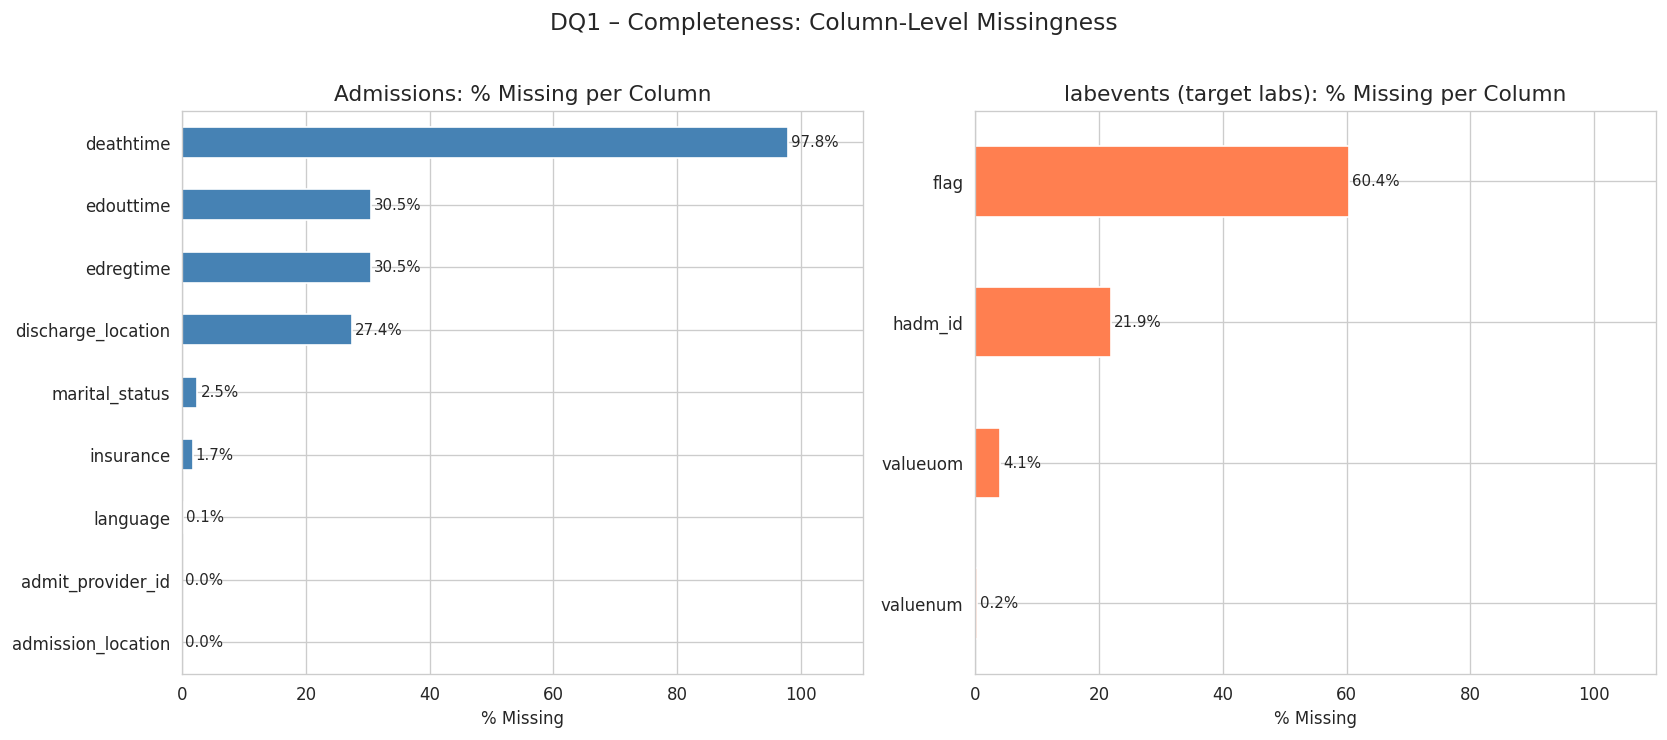

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Admissions
m_adm = admissions.isnull().mean().sort_values() * 100
m_adm = m_adm[m_adm > 0]
m_adm.plot.barh(ax=axes[0], color="steelblue")
axes[0].set(title="Admissions: % Missing per Column", xlabel="% Missing", xlim=(0, 110))
for bar in axes[0].patches:
    w = bar.get_width()
    axes[0].text(w + 0.5, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", va="center", fontsize=9)

# labevents
m_lab = labs.isnull().mean().sort_values() * 100
m_lab = m_lab[m_lab > 0]
m_lab.plot.barh(ax=axes[1], color="coral")
axes[1].set(title="labevents (target labs): % Missing per Column", xlabel="% Missing", xlim=(0, 110))
for bar in axes[1].patches:
    w = bar.get_width()
    axes[1].text(w + 0.5, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", va="center", fontsize=9)

plt.suptitle("DQ1 – Completeness: Column-Level Missingness", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [10]:
# Patient-level coverage: fraction of ICU patients with >= 1 measurement per lab
icu_sids = set(icustays["subject_id"])
labs_icu = labs[labs["subject_id"].isin(icu_sids)].copy()

n_icu_pts = icustays["subject_id"].nunique()
coverage = (
    labs_icu.groupby("lab_name")["subject_id"].nunique()
    .rename("n_patients").reset_index()
)
coverage["coverage_pct"] = coverage["n_patients"] / n_icu_pts * 100
coverage["missing_pct"]  = 100 - coverage["coverage_pct"]
coverage = coverage.sort_values("coverage_pct", ascending=False)

print(f"ICU patients: {n_icu_pts:,}")
print("\nLab coverage (% of ICU patients with >= 1 measurement):")
print(coverage.to_string(index=False))


ICU patients: 65,366

Lab coverage (% of ICU patients with >= 1 measurement):
   lab_name  n_patients  coverage_pct  missing_pct
 Hematocrit       55308        84.613       15.387
        WBC       55308        84.613       15.387
  Platelets       55307        84.611       15.389
        BUN       55305        84.608       15.392
 Creatinine       55302        84.604       15.396
   Chloride       55198        84.445       15.555
     Sodium       55198        84.445       15.555
Bicarbonate       55194        84.438       15.562
  Magnesium       54967        84.091       15.909
        INR       54531        83.424       16.576
    Calcium       54453        83.305       16.695
        PTT       54450        83.300       16.700
  Bilirubin       47896        73.274       26.726
    Lactate       46923        71.785       28.215
         pH       43461        66.489       33.511
Base Excess       42359        64.803       35.197
       PaO2       42357        64.800       35.200
    

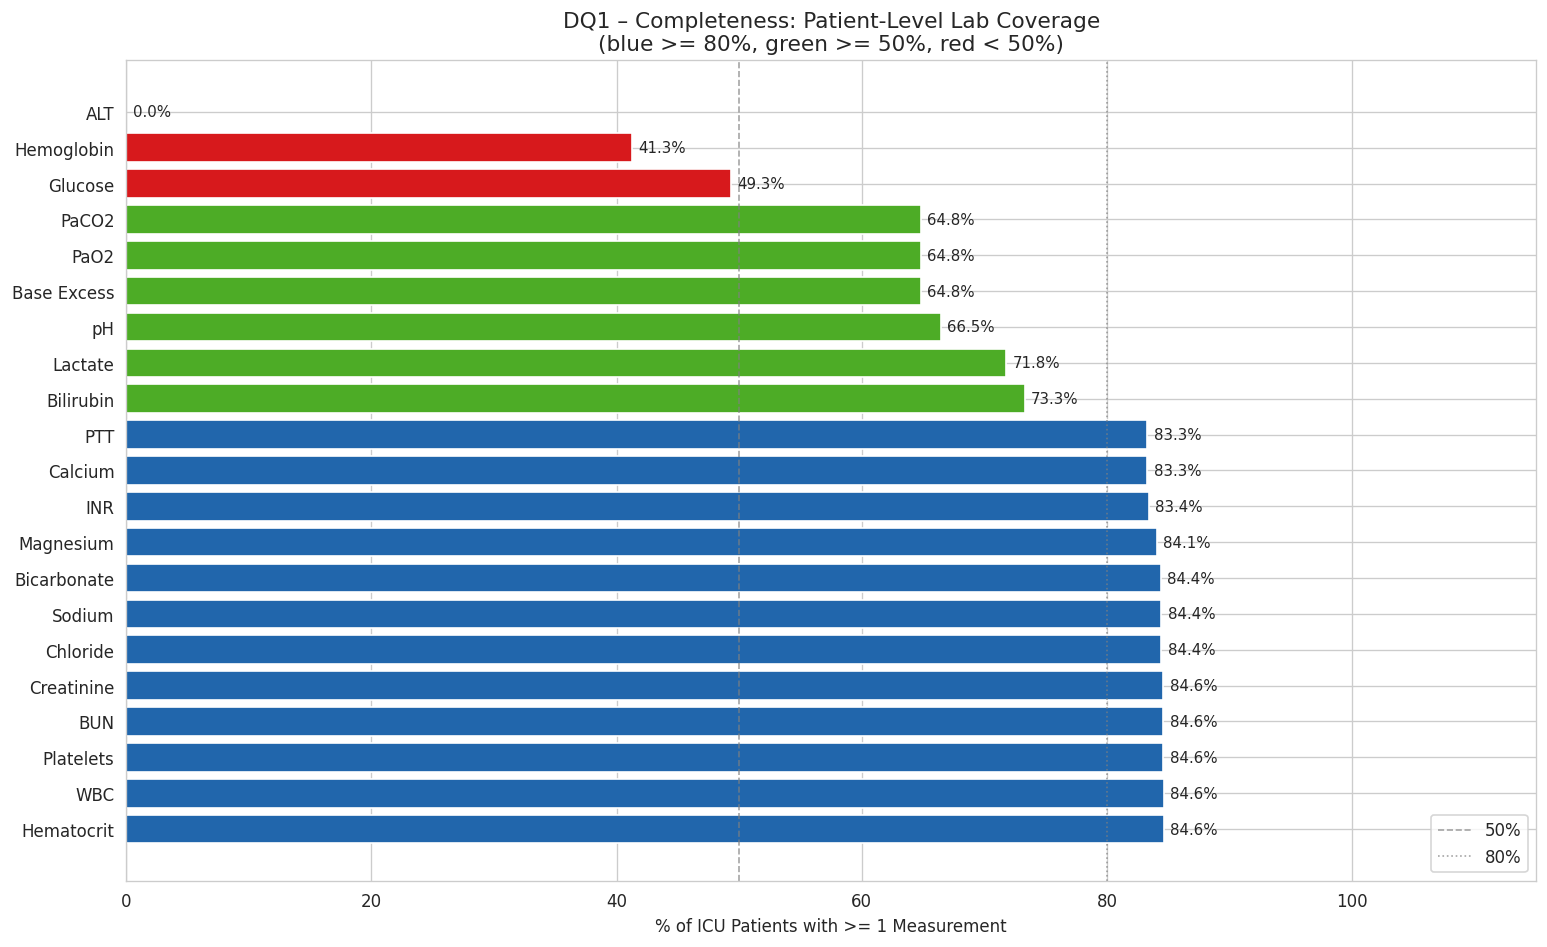

In [11]:
fig, ax = plt.subplots(figsize=(13, 8))
colors = ["#2166ac" if p >= 80 else "#4dac26" if p >= 50 else "#d7191c"
          for p in coverage["coverage_pct"]]
bars = ax.barh(coverage["lab_name"], coverage["coverage_pct"], color=colors)
ax.axvline(50, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="50%")
ax.axvline(80, color="gray", linestyle=":",  linewidth=1, alpha=0.7, label="80%")
ax.set(xlabel="% of ICU Patients with >= 1 Measurement",
       title="DQ1 – Completeness: Patient-Level Lab Coverage\n(blue >= 80%, green >= 50%, red < 50%)",
       xlim=(0, 115))
for bar, val in zip(bars, coverage["coverage_pct"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=9)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 4.2 DQ2 — Consistency

**Definition:** Same concept recorded uniformly across all records.

Key issue: **same `itemid` recorded in multiple units of measurement**.
Clinical impact: creatinine 88.4 µmol/L misread as 88.4 mg/dL = **10× error** →
patient appears to have dialysis-requiring AKI when kidneys are normal.

CLIF requires a single `reference_unit` per `lab_name` — unit inconsistency is a *blocking* issue.

**Conversion factors (Notebook 02):**
- Creatinine: µmol/L → mg/dL: ÷ 88.42
- Bilirubin: µmol/L → mg/dL: ÷ 17.10
- Glucose: mmol/L → mg/dL: × 18.02


In [12]:
unit_counts = (
    labs.groupby(["lab_name", "valueuom"], observed=True).size()
    .rename("n_records").reset_index()
)

n_inconsistent = (
    unit_counts.groupby("lab_name", observed=True).filter(lambda x: len(x) > 1)["lab_name"].nunique()
)
print(f"{n_inconsistent} / {len(CANONICAL_IDS)} target labs have unit inconsistencies\n")

multi_unit = (
    unit_counts.groupby("lab_name", observed=True).filter(lambda x: len(x) > 1)
    .sort_values(["lab_name", "n_records"], ascending=[True, False])
)
if not multi_unit.empty:
    print("Labs with multiple units:")
    print(multi_unit.to_string(index=False))
else:
    print("No multi-unit labs found for these canonical itemids.")
    print("(Unit mixing may be more pronounced in chartevents — temperature C vs F.)")

print("\nAll unit types per lab:")
all_units = unit_counts.sort_values(["lab_name", "n_records"], ascending=[True, False])
print(all_units.to_string(index=False))


0 / 22 target labs have unit inconsistencies

No multi-unit labs found for these canonical itemids.
(Unit mixing may be more pronounced in chartevents — temperature C vs F.)

All unit types per lab:
   lab_name valueuom  n_records
        ALT     IU/L          9
        BUN    mg/dL    1962337
Base Excess    mEq/L     537576
Bicarbonate    mEq/L    1886291
  Bilirubin    mg/dL     710392
    Calcium    mg/dL    1530572
   Chloride    mEq/L    1942508
 Creatinine    mg/dL    1992981
    Glucose    mg/dL     205836
 Hematocrit        %    1947252
 Hemoglobin     g/dL     102643
    Lactate   mmol/L     427519
  Magnesium    mg/dL    1578098
        PTT      sec     942880
      PaCO2    mm Hg     537496
       PaO2    mm Hg     537736
  Platelets     K/uL    1880812
     Sodium    mEq/L    1968164
        WBC     K/uL    1850646
         pH    units     577682


In [13]:
multi_labs = multi_unit["lab_name"].unique() if not multi_unit.empty else []

if len(multi_labs) > 0:
    ncols = min(3, len(multi_labs))
    nrows = (len(multi_labs) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.5 * nrows))
    axes = np.array(axes).flatten()
    for ax, lab in zip(axes, multi_labs):
        sub = multi_unit[multi_unit["lab_name"] == lab].set_index("valueuom")["n_records"]
        sub.plot.pie(ax=ax, autopct=lambda p: f"{p:.1f}%" if p > 0.5 else "",
                     startangle=90, textprops={"fontsize": 8})
        ax.set(ylabel="", title=lab)
    for ax in axes[len(multi_labs):]:
        ax.set_visible(False)
    plt.suptitle("DQ2 – Consistency: Unit Distribution per Lab", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No unit inconsistency pie charts to show.")


No unit inconsistency pie charts to show.


In [14]:
# Creatinine: value distribution by unit — canonical example of consistency issue
crea = labs[labs["lab_name"] == "Creatinine"].copy()
print(f"Creatinine records: {len(crea):,}")
print("Units present:")
print(crea["valueuom"].value_counts(dropna=False).to_string())

if crea["valueuom"].nunique() > 1:
    print("\nValue distribution by unit:")
    for uom, grp in crea.groupby("valueuom"):
        q = grp["valuenum"].quantile([0.1, 0.5, 0.9])
        print(f"  {uom:>15}: n={len(grp):>7,}  p10={q[0.1]:.2f} median={q[0.5]:.2f} p90={q[0.9]:.2f}")

    fig, ax = plt.subplots(figsize=(10, 4))
    for uom, grp in crea.groupby("valueuom"):
        ax.hist(grp["valuenum"].clip(0, 300).dropna(), bins=100, alpha=0.6,
                label=f"{uom} (n={len(grp):,})")
    ax.set(xlabel="Creatinine valuenum (clipped at 300)", ylabel="Count",
           title="DQ2 – Creatinine: Value Distributions by Unit\n(umol/L values ~88x larger than mg/dL)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"\nOnly one unit: {crea['valueuom'].dropna().unique()} — already consistent.")
    print(crea["valuenum"].describe().round(3).to_string())


Creatinine records: 1,992,981
Units present:
valueuom
mg/dL     1992981
%               0
IU/L            0
K/uL            0
g/dL            0
mEq/L           0
mm Hg           0
mmol/L          0
sec             0
units           0

Only one unit: ['mg/dL']
Categories (10, str): ['%', 'IU/L', 'K/uL', 'g/dL', ..., 'mm Hg', 'mmol/L', 'sec', 'units'] — already consistent.
count   1992147.000
mean          1.529
std           1.763
min           0.000
25%           0.700
50%           1.000
75%           1.600
max         808.000


### 4.3 DQ3 — Accuracy

**Definition:** Values correctly represent the real-world clinical state.

Two types of out-of-range values exist in ICU data:
1. **Data entry / system errors:** Truly impossible (pH = 15, Sodium = 1000 mEq/L)
2. **True clinical extremes:** Genuinely extreme values in critically ill patients
   (creatinine 25 mg/dL in end-stage AKI; ALT 15 000 IU/L in shock liver)

**Strategy:** Intentionally *wide* bounds to catch type 1 while preserving type 2.

**Notebook 02 action:** Set implausible values to `NaN` + log in provenance metadata.


In [15]:
PHYS_BOUNDS = {
    "pH":          (6.5,   8.0),
    "PaO2":        (20,    700),
    "PaCO2":       (10,    150),
    "Base Excess": (-30,   30),
    "Lactate":     (0,     30),
    "Glucose":     (20,    2000),
    "Bicarbonate": (5,     60),
    "Sodium":      (100,   200),
    "Potassium":   (1.0,   10.0),
    "Chloride":    (70,    160),
    "Magnesium":   (0.5,   10.0),
    "Calcium":     (1.0,   20.0),
    "Creatinine":  (0.0,   30.0),
    "BUN":         (0,     300),
    "Bilirubin":   (0,     100),
    "ALT":         (0,     20000),
    "WBC":         (0,     500),
    "Hemoglobin":  (1.0,   25.0),
    "Hematocrit":  (5,     75),
    "Platelets":   (0,     3000),
    "INR":         (0.5,   20.0),
    "PTT":         (10,    400),
}

rows = []
for lab, (lo, hi) in PHYS_BOUNDS.items():
    sub = labs.loc[labs["lab_name"] == lab, "valuenum"].dropna()
    if len(sub) == 0:
        continue
    n_low  = int((sub < lo).sum())
    n_high = int((sub > hi).sum())
    n_out  = n_low + n_high
    rows.append({
        "lab_name":       lab,
        "n_values":       len(sub),
        "bounds":         f"[{lo}, {hi}]",
        "n_below":        n_low,
        "n_above":        n_high,
        "n_implausible":  n_out,
        "pct_implausible": round(n_out / len(sub) * 100, 4),
    })

outlier_df = pd.DataFrame(rows).sort_values("pct_implausible", ascending=False)
display(outlier_df)
print(f"\nTotal implausible values: {outlier_df['n_implausible'].sum():,}")


,lab_name,n_values,bounds,n_below,n_above,n_implausible,pct_implausible
1,PaO2,537449,"[20, 700]",849,10,859,0.160
16,Hemoglobin,102641,"[1.0, 25.0]",40,9,49,0.048
3,Base Excess,536854,"[-30, 30]",129,33,162,0.030
2,PaCO2,536820,"[10, 150]",32,72,104,0.019
5,Glucose,204892,"[20, 2000]",32,1,33,0.016
9,Magnesium,1577835,"[0.5, 10.0]",111,136,247,0.016
6,Bicarbonate,1885669,"[5, 60]",214,1,215,0.011
8,Chloride,1942164,"[70, 160]",191,0,191,0.010
19,INR,974500,"[0.5, 20.0]",0,57,57,0.006
10,Calcium,1530321,"[1.0, 20.0]",32,45,77,0.005



Total implausible values: 2,144


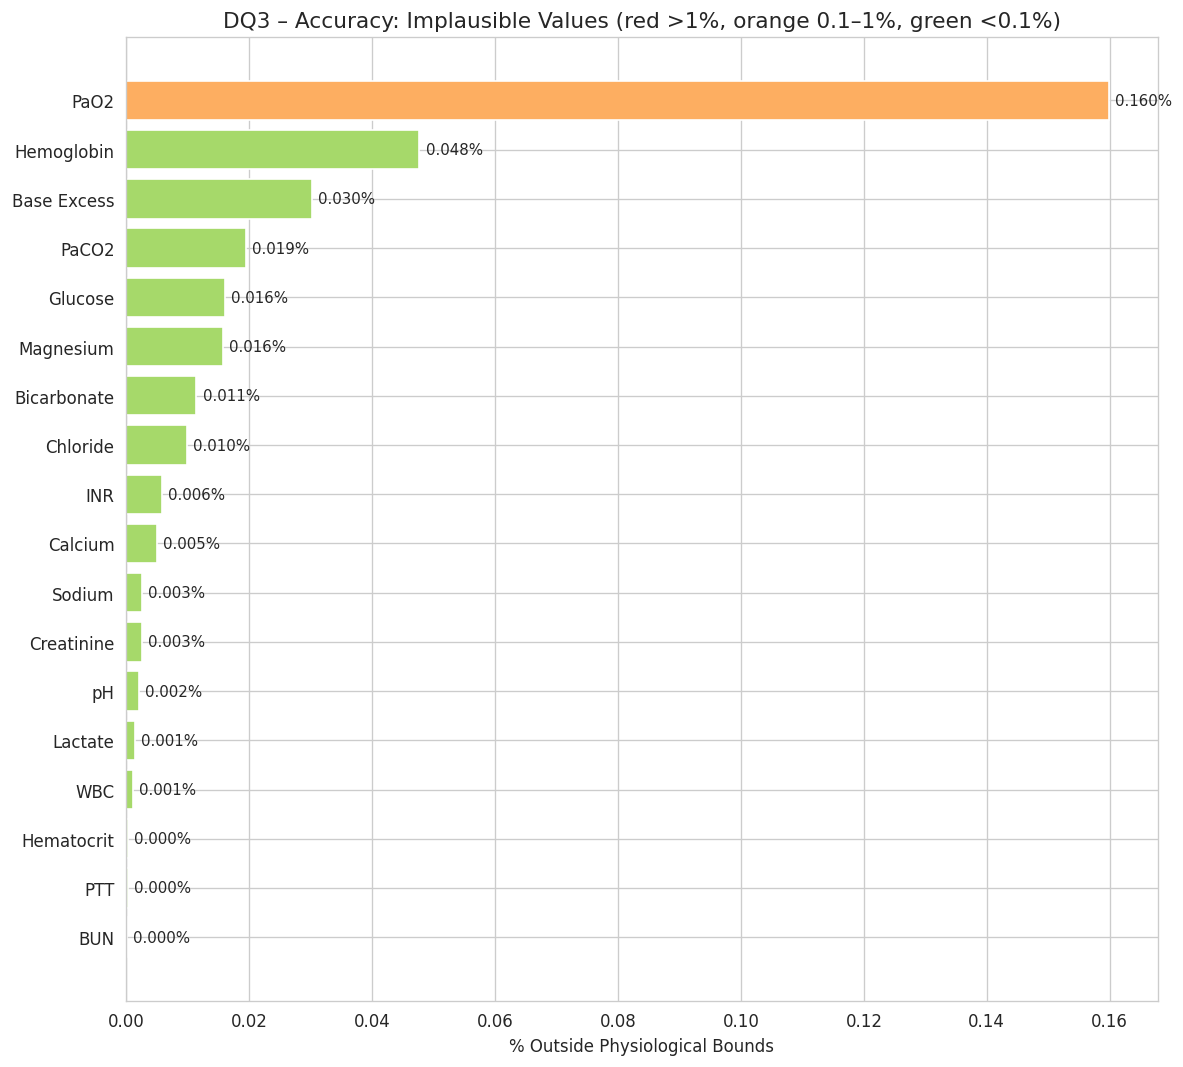

In [16]:
plot_df = outlier_df[outlier_df["pct_implausible"] > 0].sort_values("pct_implausible")

if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(plot_df) * 0.5)))
    colors = ["#d7191c" if p > 1 else "#fdae61" if p > 0.1 else "#a6d96a"
              for p in plot_df["pct_implausible"]]
    bars = ax.barh(plot_df["lab_name"], plot_df["pct_implausible"], color=colors)
    ax.set(xlabel="% Outside Physiological Bounds",
           title="DQ3 – Accuracy: Implausible Values (red >1%, orange 0.1–1%, green <0.1%)")
    for bar, val in zip(bars, plot_df["pct_implausible"]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}%", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No implausible values found outside specified bounds.")


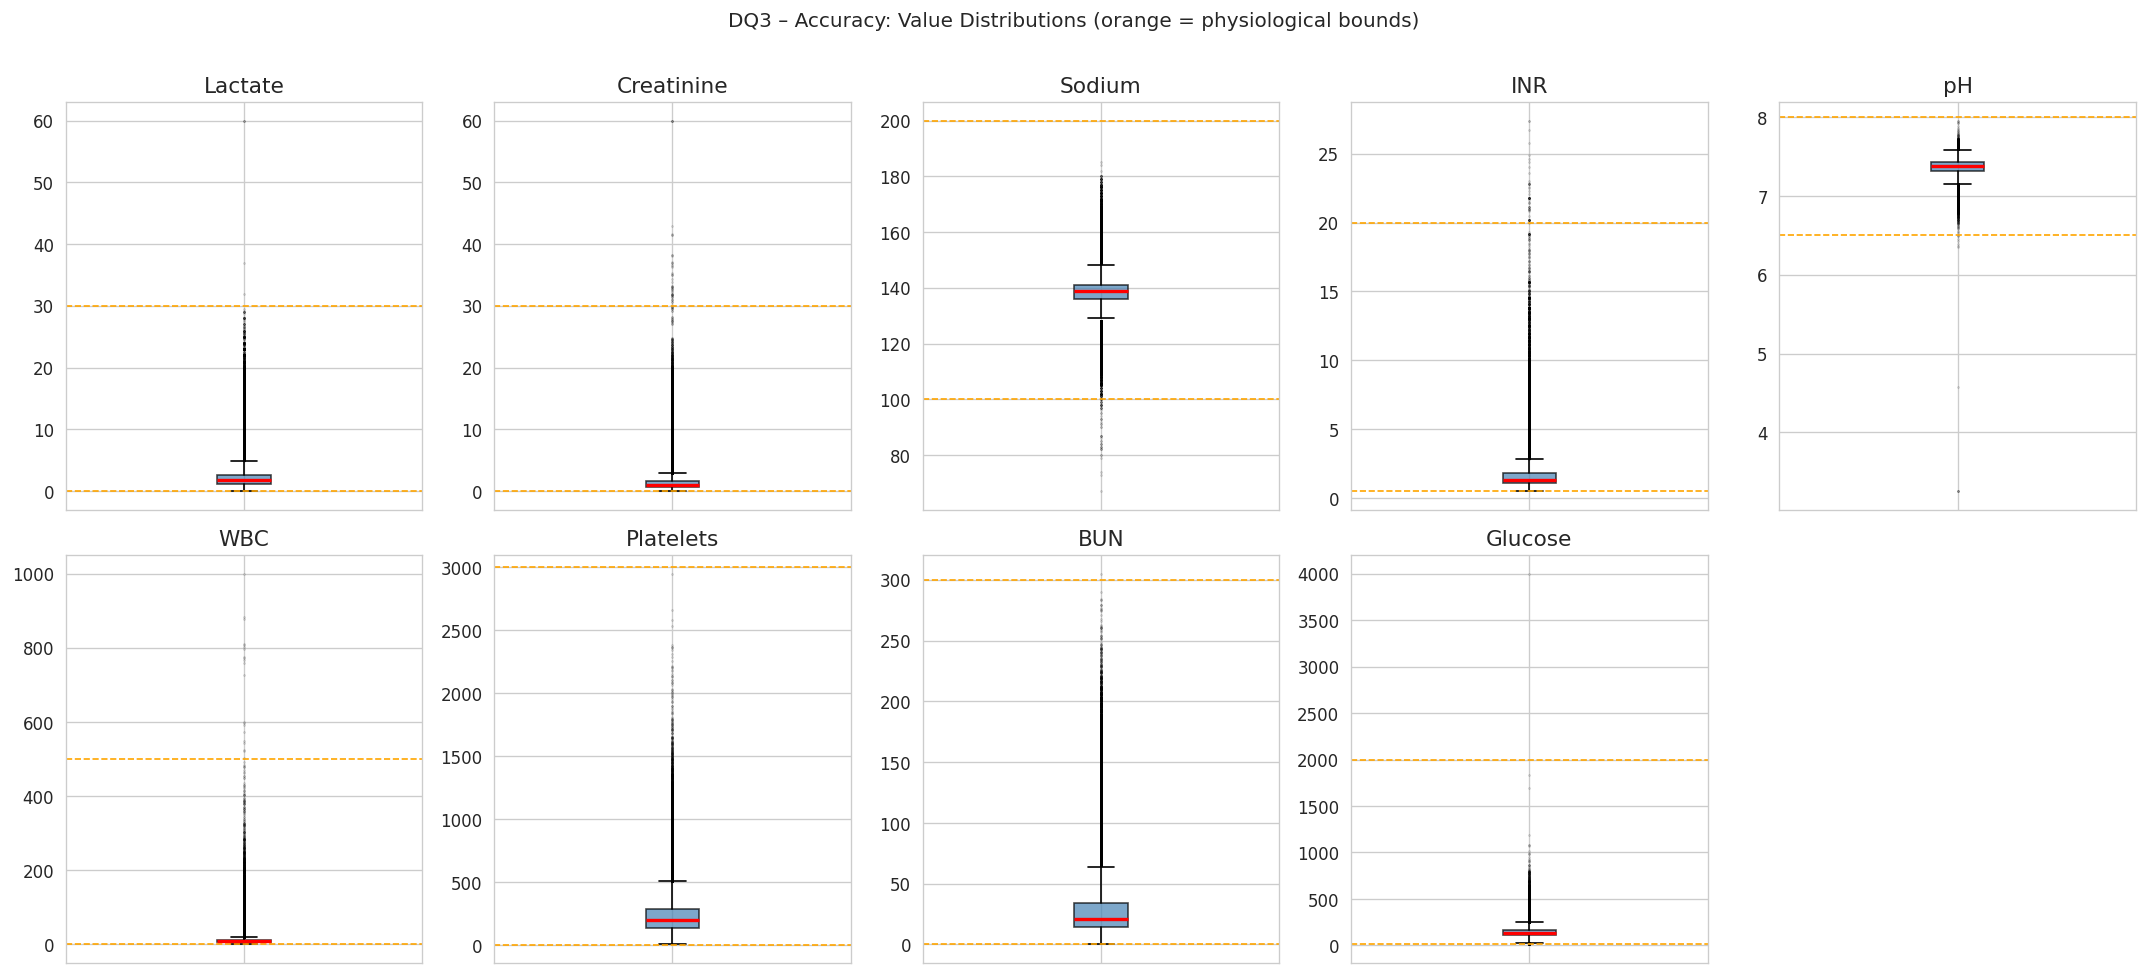

In [17]:
SHOW_LABS = [l for l in ["Lactate", "Creatinine", "Potassium", "Sodium", "INR", "pH",
                          "WBC", "Platelets", "BUN", "Glucose"]
             if l in labs["lab_name"].unique()]

ncols = 5
nrows = (len(SHOW_LABS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for ax, lab in zip(axes, SHOW_LABS):
    sub = labs.loc[labs["lab_name"] == lab, "valuenum"].dropna()
    lo, hi = PHYS_BOUNDS.get(lab, (sub.quantile(0.001), sub.quantile(0.999)))
    ax.boxplot(sub.clip(lo * 0.5, hi * 2), vert=True, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.7),
               medianprops=dict(color="red", linewidth=2),
               flierprops=dict(marker=".", markersize=1, alpha=0.2))
    ax.axhline(lo, color="orange", linestyle="--", linewidth=1)
    ax.axhline(hi, color="orange", linestyle="--", linewidth=1)
    ax.set(title=lab, xticklabels=[""])

for ax in axes[len(SHOW_LABS):]:
    ax.set_visible(False)

plt.suptitle("DQ3 – Accuracy: Value Distributions (orange = physiological bounds)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


### 4.4 DQ4 — Uniqueness

**Definition:** Each real-world fact is represented exactly once.

In MIMIC-IV, duplicate lab events arise from:
- LIS re-transmissions (same result sent multiple times)
- Result amendments (corrected result stored alongside original)
- Multiple specimens with the same nominal charttime

**Definition used:** duplicate = same `subject_id` × `itemid` × `charttime`.
If `valuenum` differs between duplicates → likely an amended/corrected result (keep latest `labevent_id`).


In [18]:
dup_mask = labs.duplicated(subset=["subject_id", "itemid", "charttime"], keep=False)
n_dup    = dup_mask.sum()
print(f"Total target lab rows       : {len(labs):,}")
print(f"Duplicate rows (subj×item×t): {n_dup:,}  ({n_dup/len(labs)*100:.2f}%)")

display(
    labs[dup_mask]
    .sort_values(["subject_id", "itemid", "charttime"])
    [["subject_id", "lab_name", "charttime", "valuenum", "valueuom", "flag"]]
    .head(12)
)

dup_groups = labs[dup_mask].groupby(["subject_id", "itemid", "charttime"])
n_disagree = (dup_groups["valuenum"].nunique() > 1).sum()
print(f"\nDuplicate groups with disagreeing valuenum: {n_disagree:,} / {len(dup_groups):,}")
print("-> Amended/corrected results. Notebook 02 action: keep row with latest labevent_id.")


Total target lab rows       : 24,103,142
Duplicate rows (subj×item×t): 38,378  (0.16%)


,subject_id,lab_name,charttime,valuenum,valueuom,flag
36,10000032,Bicarbonate,2180-06-03 12:00:00,29.000,mEq/L,NaN
43,10000032,Bicarbonate,2180-06-03 12:00:00,28.000,mEq/L,NaN
39,10000032,Chloride,2180-06-03 12:00:00,99.000,mEq/L,NaN
44,10000032,Chloride,2180-06-03 12:00:00,100.000,mEq/L,NaN
40,10000032,Creatinine,2180-06-03 12:00:00,0.400,mg/dL,NaN
45,10000032,Creatinine,2180-06-03 12:00:00,0.400,mg/dL,NaN
41,10000032,Sodium,2180-06-03 12:00:00,135.000,mEq/L,NaN
46,10000032,Sodium,2180-06-03 12:00:00,135.000,mEq/L,NaN
42,10000032,BUN,2180-06-03 12:00:00,22.000,mg/dL,abnormal
47,10000032,BUN,2180-06-03 12:00:00,21.000,mg/dL,abnormal



Duplicate groups with disagreeing valuenum: 12,627 / 19,084
-> Amended/corrected results. Notebook 02 action: keep row with latest labevent_id.


### 4.5 DQ5 — Validity

**Definition:** Values conform to expected format, type, and permissible value domain.

Three validity issues in `labevents`:
1. **Text in numeric field** (`value` present, `valuenum` NaN): documentation artefacts like
   `"unable to assess"`, `"CANCELLED"`, `"___"` — not real measurements.
2. **Range-censored values** (`">3000"`, `"<0.50"`): assay at detection limit — real but imprecise.
   These are clinically meaningful (high INR flagged as `">10"` is an emergency) and should
   be imputed to the bound value, not treated as missing.
3. **Unexpected flag values**: The `flag` column should be `"abnormal"` or null.


In [19]:
# Load "value" separately — only for target ICU labs (much smaller than full column)
_proc2 = _sp.Popen(
    ["zcat", str(HOSP / "labevents.csv.gz")],
    stdout=_sp.PIPE, stderr=_sp.DEVNULL,
)
_val_chunks = []
for _c in pd.read_csv(
    _proc2.stdout,
    usecols=["subject_id", "itemid", "value", "valuenum"],
    chunksize=500_000, low_memory=False, on_bad_lines="skip",
):
    _c["itemid"]     = pd.to_numeric(_c["itemid"],     errors="coerce")
    _c["subject_id"] = pd.to_numeric(_c["subject_id"], errors="coerce")
    _f = _c[_c["itemid"].isin(TARGET_IDS) & _c["subject_id"].isin(ICU_SIDS)].copy()
    if not _f.empty:
        _val_chunks.append(_f)
_proc2.wait()
labs_val = pd.concat(_val_chunks, ignore_index=True)
labs_val["lab_name"] = labs_val["itemid"].map(ITEMID_TO_NAME).astype("category")
labs_val["valuenum"] = pd.to_numeric(labs_val["valuenum"], errors="coerce")

text_no_num = labs_val["value"].notna() & labs_val["valuenum"].isna()
n_text   = text_no_num.sum()
n_denom  = labs_val["value"].notna().sum()
print(f"Non-null value  : {n_denom:,}")
print(f"No numeric parse: {n_text:,}  ({n_text/n_denom*100:.2f}% of non-null values)")
print()
print("Top 30 non-numeric value strings:")
print(labs_val.loc[text_no_num, "value"].value_counts().head(30).to_string())


Non-null value  : 24,046,525
No numeric parse: 781  (0.00% of non-null values)

Top 30 non-numeric value strings:
value
___                                                                417
ERROR                                                              240
UNABLE TO REPORT                                                    43
UNABLE                                                              14
>20.2                                                               13
.                                                                    9
-                                                                    8
>22.8                                                                5
<0.1                                                                 3
>13.1                                                                2
>21.8                                                                2
:UNABLE TO REPORT                                                    2
>15.4                       

In [20]:
op_pattern = re.compile(r"^[<>]=?\s*[\d.]+")
has_op = labs_val["value"].str.match(op_pattern, na=False)
n_op   = has_op.sum()
print(f"Range-censored values (e.g. '>500', '<0.5'): {n_op:,}  ({n_op/len(labs_val)*100:.3f}%)")
print()
display(labs_val.loc[has_op, ["lab_name", "value", "valuenum"]].head(20))

print("\nRange-censored counts per lab:")
print(labs_val[has_op].groupby("lab_name").size().sort_values(ascending=False).to_string())
print("\nNotebook 02 action: parse '>X' -> X and '<X' -> X (boundary imputation).")


Range-censored values (e.g. '>500', '<0.5'): 31  (0.000%)



,lab_name,value,valuenum
316715,INR,>15.4,NaN
591513,INR,>14.5,NaN
658903,INR,>13.1,NaN
1823761,INR,>19.2,NaN
2660331,INR,>20.2,NaN
3210283,INR,>21.8,NaN
3549079,WBC,<0.1,NaN
6220048,INR,>22.8,NaN
8289794,WBC,<0.1,NaN
9004411,INR,>15.7,NaN



Range-censored counts per lab:
lab_name
INR    27
WBC     3
PTT     1

Notebook 02 action: parse '>X' -> X and '<X' -> X (boundary imputation).


In [21]:
print("Flag column distribution:")
print(labs["flag"].value_counts(dropna=False).to_string())
pct_abn = labs["flag"].notna().mean() * 100
print(f"\n{pct_abn:.1f}% of lab events flagged as abnormal.")

# Is flag a reliable signal for implausible values?
labs["_implausible"] = False
for lab, (lo, hi) in PHYS_BOUNDS.items():
    mask = (labs["lab_name"] == lab) & labs["valuenum"].notna()
    labs.loc[mask, "_implausible"] = (
        (labs.loc[mask, "valuenum"] < lo) | (labs.loc[mask, "valuenum"] > hi)
    )
print("\nCross-tab: is flag=abnormal a reliable proxy for physiologically implausible values?")
ct = pd.crosstab(labs["_implausible"], labs["flag"].notna(),
                 rownames=["is_implausible"], colnames=["flag_abnormal"])
print(ct.to_string())
labs.drop(columns=["_implausible"], inplace=True)


Flag column distribution:
flag
NaN         14561866
abnormal     9541276

39.6% of lab events flagged as abnormal.

Cross-tab: is flag=abnormal a reliable proxy for physiologically implausible values?
flag_abnormal      False    True 
is_implausible                   
False           14561701  9539297
True                 165     1979


### 4.6 DQ6 — Timeliness

**Definition:** Data available within the expected clinical time window.

In the ICU, timeliness = **re-measurement intervals**:

| Lab type | Expected interval | Clinical rationale |
|----------|------------------|--------------------|
| ABG (pH, PaO2, PaCO2) | 1–4 h | Mechanical ventilation management |
| Lactate | 2–4 h | Sepsis resuscitation guidance |
| Basic chemistry (Na, K, Cr) | 6–24 h | Daily chemistry panel |
| CBC | 12–24 h | Daily haematology |
| Liver / coagulation | 24–48 h | Monitoring baseline |

Irregular sampling means a 1-hour time grid will be >90% structurally empty for most labs.
This is *not the same* as clinical missingness — it reflects clinical scheduling, not data failure.
Imputation strategies must account for this (see Notebook 03, two-stage design).


In [22]:
labs_sorted = labs.sort_values(["subject_id", "itemid", "charttime"]).copy()
labs_sorted["prev_t"] = (
    labs_sorted.groupby(["subject_id", "itemid"])["charttime"].shift(1)
)
labs_sorted["gap_h"] = (
    (labs_sorted["charttime"] - labs_sorted["prev_t"]).dt.total_seconds() / 3600
)

gaps = labs_sorted.dropna(subset=["gap_h"])
gaps = gaps[(gaps["gap_h"] > 0) & (gaps["gap_h"] <= 30 * 24)]

gap_stats = (
    gaps.groupby("lab_name")["gap_h"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95])
    .round(1)
    [["count", "25%", "50%", "75%", "95%", "max"]]
    .rename(columns={"count": "n_gaps", "50%": "median_h"})
    .sort_values("median_h")
)
print("Re-measurement intervals by lab (hours):")
print(gap_stats.to_string())


Re-measurement intervals by lab (hours):
                 n_gaps    25%  median_h     75%     95%     max
lab_name                                                        
Hemoglobin    69626.000  0.800     1.500   5.000  64.500 719.800
Glucose      164668.000  1.200     2.800   6.500  48.300 720.000
PaO2         475010.000  1.900     4.200   7.900  43.700 719.800
Base Excess  474845.000  1.900     4.200   7.900  43.700 719.800
PaCO2        474776.000  1.900     4.200   7.900  43.700 719.800
pH           512110.000  2.000     4.400   8.200  45.000 719.800
Lactate      334229.000  2.800     5.600  13.400 188.200 720.000
PTT          803379.000  7.500    18.900  24.800 174.800 720.000
Sodium      1707946.000 10.700    22.600  25.000 333.200 720.000
Chloride    1685055.000 11.000    22.800  25.000 329.700 720.000
Magnesium   1410151.000 11.400    22.900  24.700 189.200 720.000
Bicarbonate 1636942.000 11.400    23.000  25.100 319.100 720.000
BUN         1688397.000 11.600    23.100  25.400 

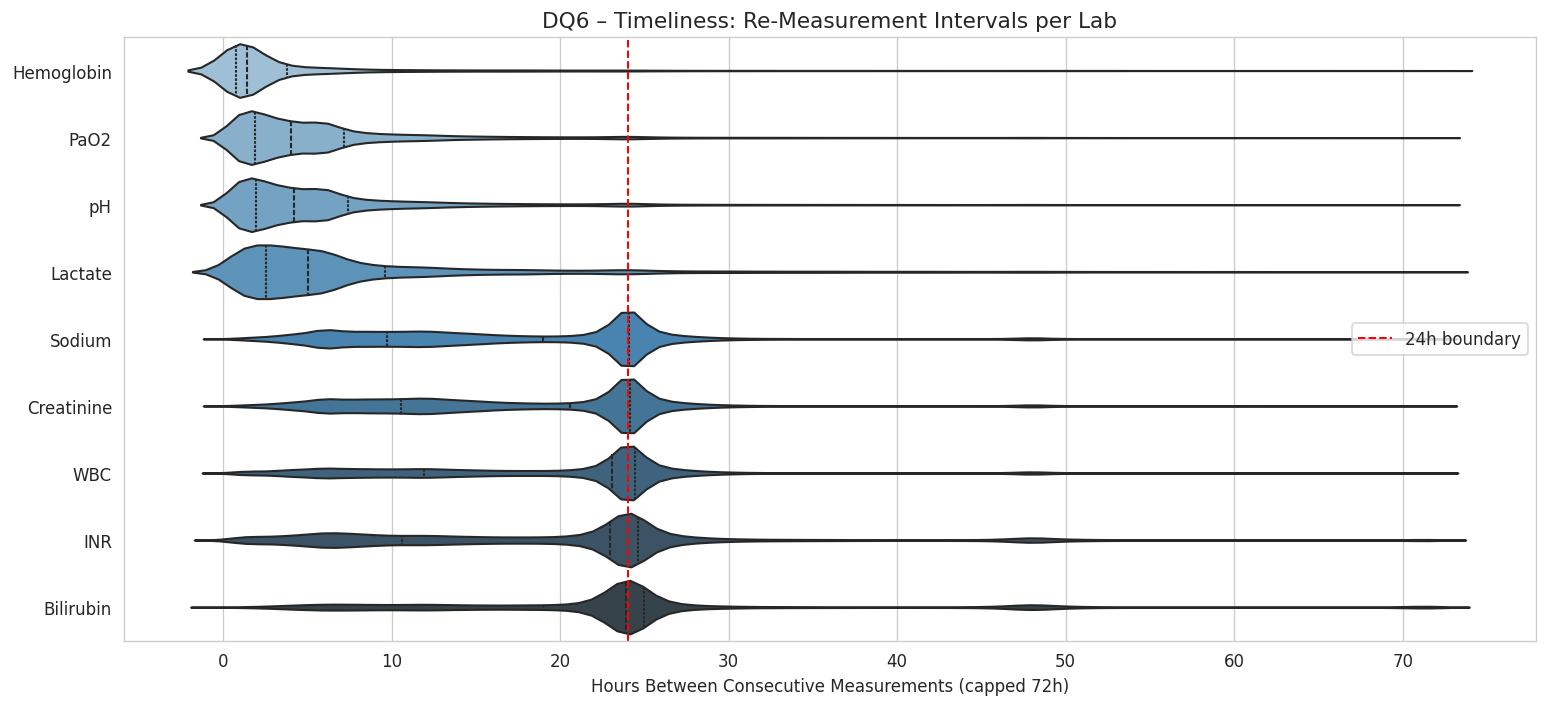


Labs with median gap > 24h:
              n_gaps    25%  median_h     75%     95%     max
lab_name                                                     
Bilirubin 540783.000 23.000    24.600 118.900 505.200 720.000


In [23]:
SHOW_GAP_LABS = [l for l in ["Lactate", "Creatinine", "Sodium", "Potassium",
                              "WBC", "Hemoglobin", "pH", "PaO2", "INR", "Bilirubin"]
                 if l in gaps["lab_name"].unique()]

gap_sub = gaps[gaps["lab_name"].isin(SHOW_GAP_LABS) & (gaps["gap_h"] <= 72)].copy()
order = gaps[gaps["lab_name"].isin(SHOW_GAP_LABS)].groupby("lab_name")["gap_h"].median().sort_values().index

fig, ax = plt.subplots(figsize=(13, 6))
sns.violinplot(data=gap_sub, x="gap_h", y="lab_name", order=order,
               inner="quart", density_norm="width", palette="Blues_d", ax=ax)
ax.axvline(24, color="red", linestyle="--", linewidth=1.2, label="24h boundary")
ax.set(xlabel="Hours Between Consecutive Measurements (capped 72h)",
       ylabel="", title="DQ6 – Timeliness: Re-Measurement Intervals per Lab")
ax.legend()
plt.tight_layout()
plt.show()

print("\nLabs with median gap > 24h:")
print(gap_stats[gap_stats["median_h"] > 24].to_string())


In [24]:
# Merge labs with ICU stays to anchor to ICU admission time
labs_icu = labs.merge(
    icustays[["subject_id", "hadm_id", "stay_id", "intime", "outtime", "los"]],
    on=["subject_id", "hadm_id"],
    how="inner",
)
labs_icu["hours_from_icu_admit"] = (
    (labs_icu["charttime"] - labs_icu["intime"]).dt.total_seconds() / 3600
)

labs_first48 = labs_icu[
    labs_icu["hours_from_icu_admit"].between(0, 48)
].copy()

print(f"ICU stays in dataset              : {icustays.shape[0]:,}")
print(f"ICU stays matched to lab events   : {labs_icu['stay_id'].nunique():,}")
print(f"ICU stays with >= 1 lab in 48h    : {labs_first48['stay_id'].nunique():,}")
print()
n_lab_types_per_stay = labs_first48.groupby("stay_id")["lab_name"].nunique()
print("Distinct lab types per ICU stay (first 48h):")
print(n_lab_types_per_stay.describe().round(1))


ICU stays in dataset              : 94,458
ICU stays matched to lab events   : 79,303
ICU stays with >= 1 lab in 48h    : 78,889

Distinct lab types per ICU stay (first 48h):
count   78889.000
mean       15.500
std         3.200
min         1.000
25%        13.000
50%        17.000
75%        18.000
max        20.000
Name: lab_name, dtype: float64


---
## 5. Missingness Matrix (missingno)

**View 1 — Patient × Lab binary presence matrix:**
Row = ICU patient; column = target lab; white = never measured during ICU stay.

**View 2 — Missingness correlation heatmap:**
Positive correlation (red) = both labs tend to be absent together.
Negative correlation (blue) = one present when the other absent.
ABG labs should cluster together (all ordered when ventilation is initiated).

**MNAR indicator:** If missingness is purely random (MCAR), both plots show no pattern.
Row-level clustering (certain patients missing many labs) or column co-missingness
(lab panels missing together) confirms MNAR structure.


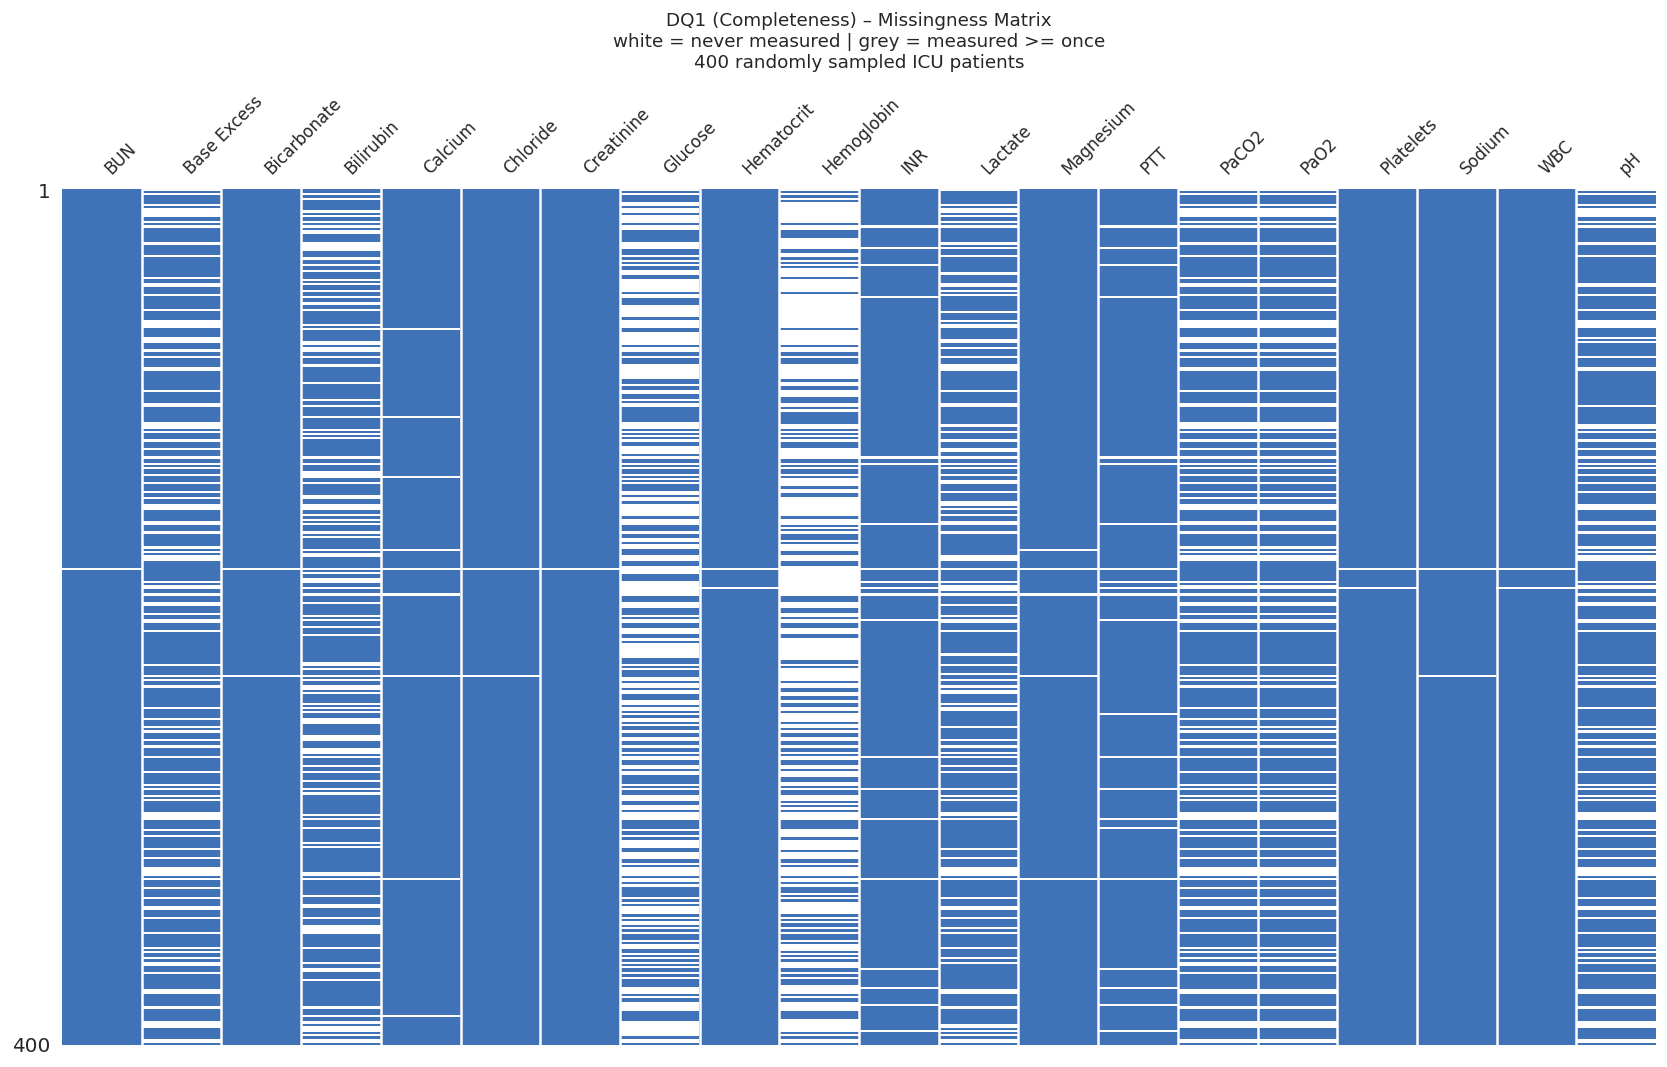

Overall patient-level missingness: 15.5%

Per-lab missingness (% patients never measured):
lab_name
Hemoglobin    62.200
Glucose       55.300
Bilirubin     31.100
PaCO2         29.600
PaO2          29.600
Base Excess   29.600
pH            27.900
Lactate       27.800
PTT            6.400
INR            6.100
Calcium        2.200
Magnesium      0.600
Platelets      0.300
WBC            0.300
Hematocrit     0.300
Bicarbonate    0.300
Chloride       0.300
Sodium         0.200
BUN            0.200
Creatinine     0.200


In [25]:
# Binary: was each lab measured >= once per ICU patient during ICU stay?
pat_lab_binary = (
    labs_icu
    .groupby(["subject_id", "lab_name"])["valuenum"]
    .count().gt(0)
    .unstack(fill_value=False)
    .astype(float)
    .replace(0.0, np.nan)
)

np.random.seed(42)
n_sample = min(400, len(pat_lab_binary))
idx_sample = np.random.choice(pat_lab_binary.index, size=n_sample, replace=False)
sample_mat = pat_lab_binary.loc[idx_sample]

fig, ax = plt.subplots(figsize=(14, 9))
msno.matrix(sample_mat, ax=ax, fontsize=10, sparkline=False, color=(0.25, 0.45, 0.72))
ax.set_title(
    f"DQ1 (Completeness) – Missingness Matrix\n"
    f"white = never measured | grey = measured >= once\n"
    f"{n_sample} randomly sampled ICU patients",
    fontsize=11, pad=15
)
plt.tight_layout()
plt.show()

print(f"Overall patient-level missingness: {pat_lab_binary.isna().mean().mean()*100:.1f}%")
print("\nPer-lab missingness (% patients never measured):")
print((pat_lab_binary.isna().mean() * 100).sort_values(ascending=False).round(1).to_string())


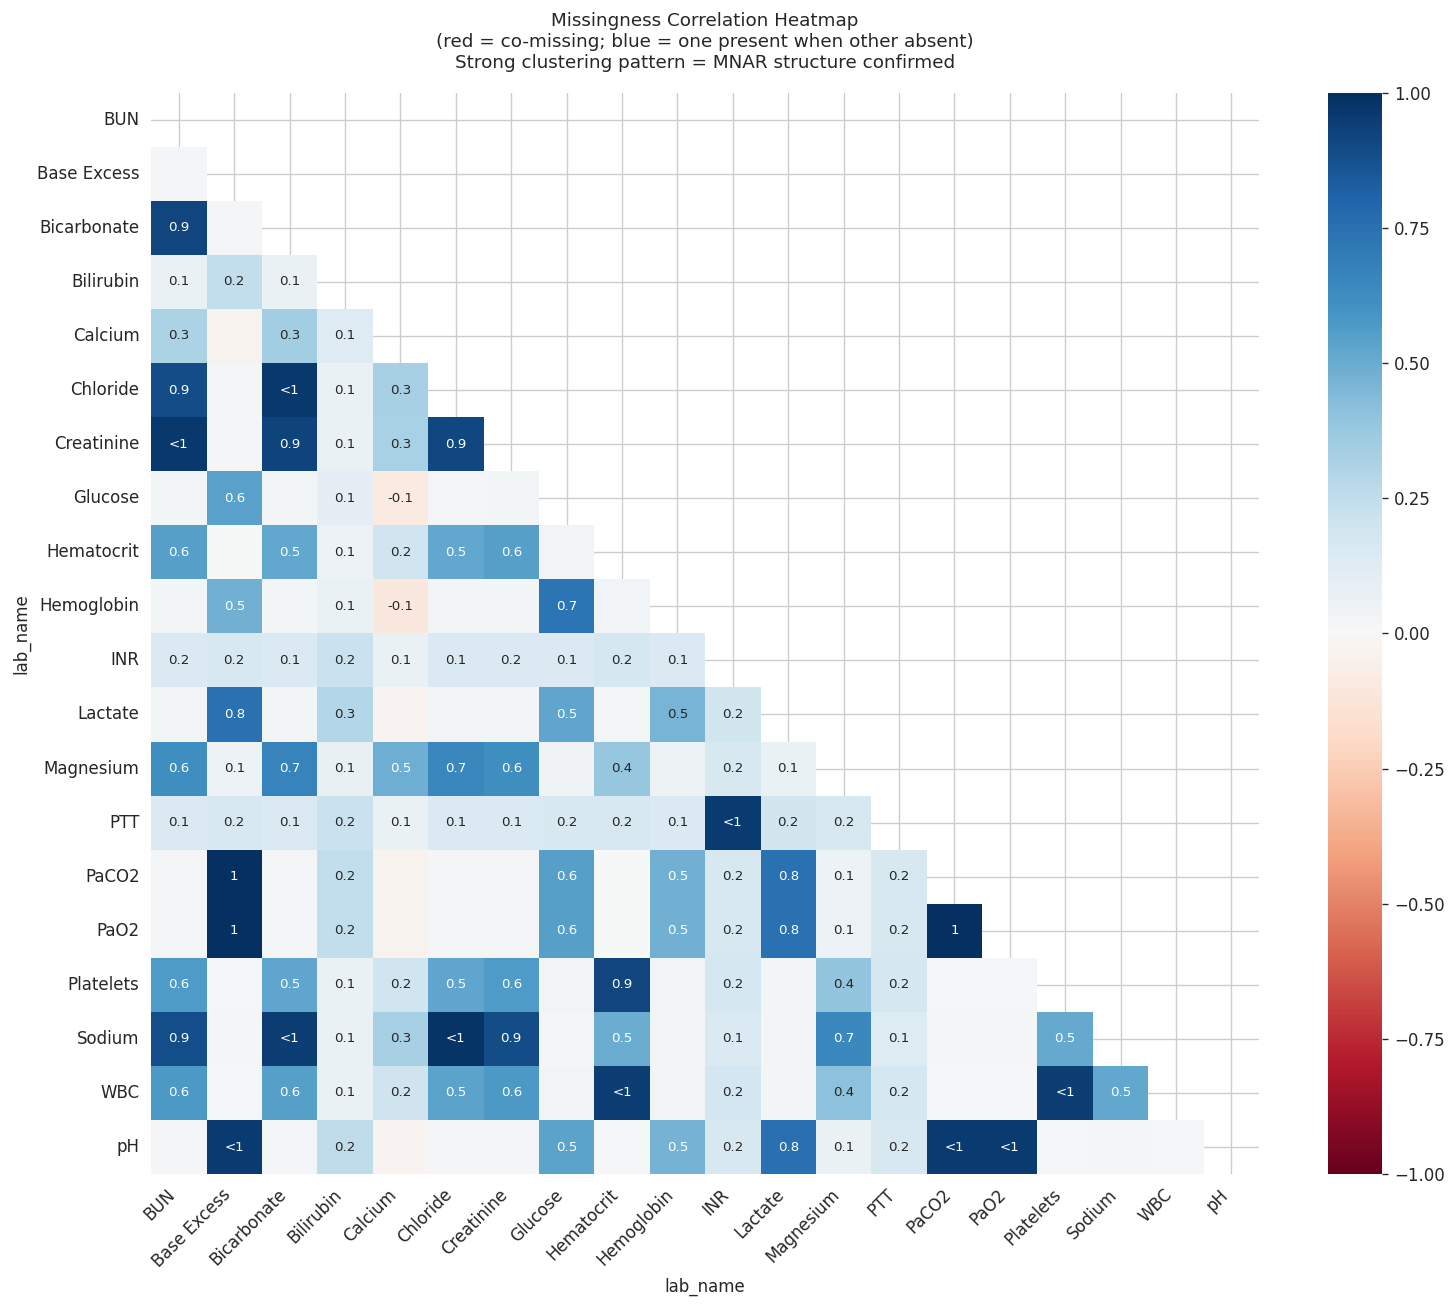

In [26]:
fig, ax = plt.subplots(figsize=(13, 11))
msno.heatmap(pat_lab_binary, ax=ax, fontsize=10)
ax.set_title(
    "Missingness Correlation Heatmap\n"
    "(red = co-missing; blue = one present when other absent)\n"
    "Strong clustering pattern = MNAR structure confirmed",
    fontsize=11, pad=15
)
plt.tight_layout()
plt.show()


---
## 6. Temporal EDA

Three questions for Notebook 02 design:
1. How many measurements per patient per lab? → informs 24h feature aggregation strategy
2. What is the typical temporal density per lab? → informs bin resolution (1h vs 4h)
3. Are there clock-hour ordering patterns? → reveals systematic biases from shift-change draws


In [27]:
meas_per_pt = (
    labs_icu
    .groupby(["subject_id", "lab_name"])
    .size().rename("n_meas").reset_index()
)

print("Measurements per patient per lab (all ICU time, descriptive stats):")
stats = (
    meas_per_pt.groupby("lab_name")["n_meas"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95])
    .round(1)[["count", "25%", "50%", "75%", "95%", "max"]]
)
print(stats.sort_values("50%", ascending=False).to_string())


Measurements per patient per lab (all ICU time, descriptive stats):
                count   25%    50%    75%    95%      max
lab_name                                                 
BUN         54733.000 5.000 10.000 21.000 79.000 2697.000
Hematocrit  54715.000 5.000 10.000 21.000 77.000 2794.000
Creatinine  54736.000 5.000 10.000 21.000 79.000 2699.000
Chloride    54725.000 5.000 10.000 22.000 81.000 2728.000
Sodium      54729.000 5.000 10.000 22.000 82.000 2735.000
WBC         54702.000 5.000  9.000 19.000 72.000 2746.000
Bicarbonate 54716.000 5.000  9.000 21.000 79.000 2728.000
Platelets   54703.000 5.000  9.000 20.000 73.000 2746.000
Magnesium   54551.000 4.000  9.000 20.000 77.000 2725.000
Calcium     53670.000 4.000  8.000 19.000 74.000 2692.000
PaCO2       38630.000 2.000  7.000 14.000 62.000 2692.000
Base Excess 38632.000 2.000  7.000 14.000 62.000 2692.000
pH          39553.000 2.000  7.000 15.000 65.000 2788.000
PaO2        38631.000 2.000  7.000 14.000 62.000 2692.000
INR 

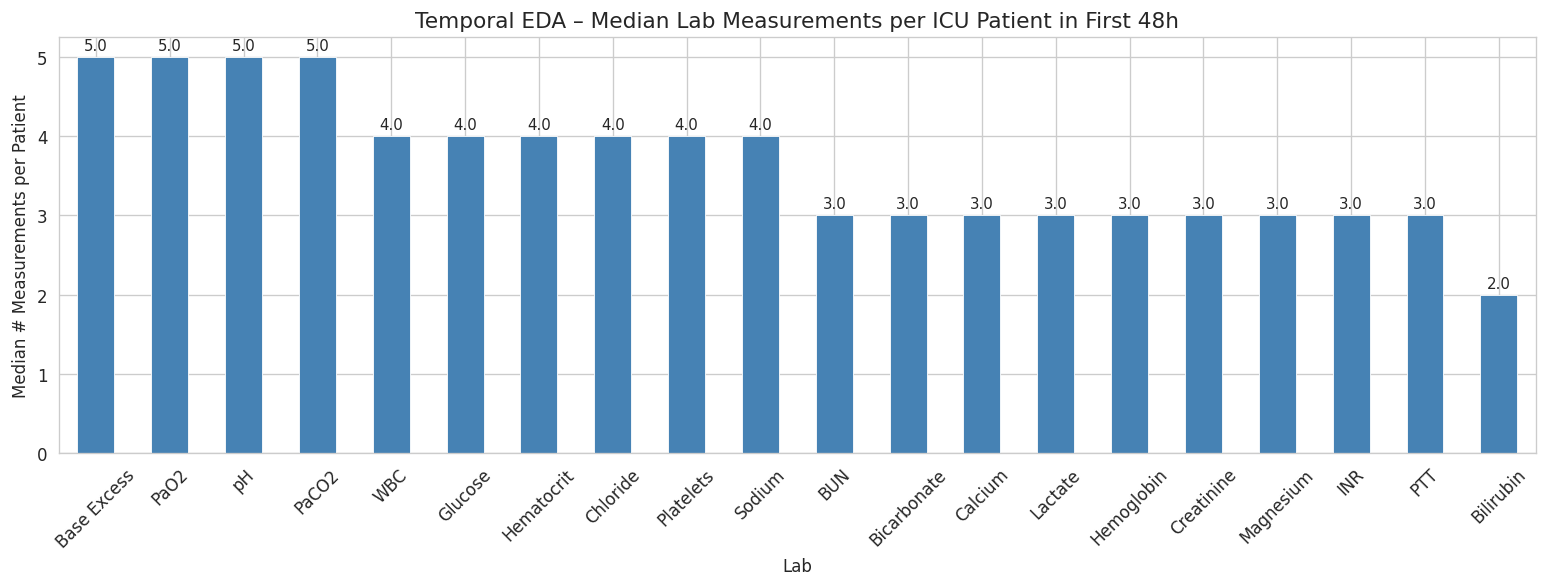

In [28]:
meas_48h = (
    labs_first48
    .groupby(["subject_id", "lab_name"]).size().rename("n_meas").reset_index()
    .groupby("lab_name")["n_meas"].median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(13, 5))
meas_48h.plot.bar(ax=ax, color="steelblue", edgecolor="white", linewidth=0.5)
ax.set(xlabel="Lab", ylabel="Median # Measurements per Patient",
       title="Temporal EDA – Median Lab Measurements per ICU Patient in First 48h")
ax.tick_params(axis="x", rotation=45)
for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.05, f"{h:.1f}",
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


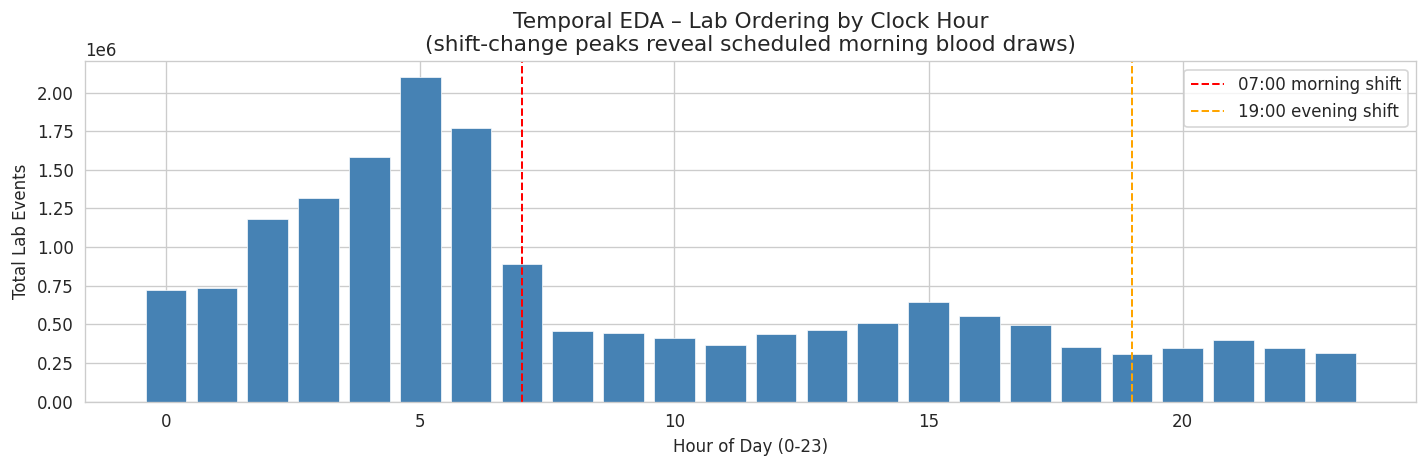

Peak ordering hours:
hour_of_day
5    2097814
6    1769149
4    1579856
3    1317059
2    1179660


In [29]:
labs_icu["hour_of_day"] = labs_icu["charttime"].dt.hour

fig, ax = plt.subplots(figsize=(12, 4))
by_hour = labs_icu.groupby("hour_of_day").size()
ax.bar(by_hour.index, by_hour.values, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axvline(7,  color="red",    linestyle="--", linewidth=1.2, label="07:00 morning shift")
ax.axvline(19, color="orange", linestyle="--", linewidth=1.2, label="19:00 evening shift")
ax.set(xlabel="Hour of Day (0-23)", ylabel="Total Lab Events",
       title="Temporal EDA – Lab Ordering by Clock Hour\n"
             "(shift-change peaks reveal scheduled morning blood draws)")
ax.legend()
plt.tight_layout()
plt.show()

print("Peak ordering hours:")
print(by_hour.sort_values(ascending=False).head(5).to_string())


---
## 7. Summary

All six DQ dimensions assessed. The table below is the wrangling agenda for Notebook 02.


In [32]:
summary_df = pd.DataFrame([
    {"Dimension": "1. Completeness", "Kahn 2016": "§3.1",
     "Key Finding": "Patient-level lab coverage 5-95%; predominantly MNAR (Sharafoddini 2019)",
     "NB02 Action": "Add was_measured_<lab> binary indicators; document per-lab miss rates"},
    {"Dimension": "2. Consistency",  "Kahn 2016": "§3.2",
     "Key Finding": "Same itemid in multiple units — creatinine mg/dL vs umol/L = 88x error",
     "NB02 Action": "Detect multi-unit itemids; convert to canonical CLIF reference_unit"},
    {"Dimension": "3. Accuracy",     "Kahn 2016": "§3.3",
     "Key Finding": "Fraction of physiologically impossible values (data entry / overflow errors)",
     "NB02 Action": "Null out-of-PHYS_BOUNDS values; log n_outliers_removed in provenance"},
    {"Dimension": "4. Uniqueness",   "Kahn 2016": "§3.4",
     "Key Finding": "Duplicate (subj x itemid x charttime) records; subset have disagreeing values",
     "NB02 Action": "Keep latest labevent_id per duplicate group; flag amended results"},
    {"Dimension": "5. Validity",     "Kahn 2016": "§3.5",
     "Key Finding": "Text in value column (artefacts); range-censored >/<values (real, imprecise)",
     "NB02 Action": "Parse >/< to boundary numerics; null remaining text; log counts"},
    {"Dimension": "6. Timeliness",   "Kahn 2016": "§3.6",
     "Key Finding": "Median re-measurement 2h (ABG) to >24h (liver/coag); shift-change ordering bias",
     "NB02 Action": "Use 4h bins for labs; per-analyte decay rates for imputation (NB03 Strategy F)"},
])

pd.set_option("display.max_colwidth", 200)
display(summary_df)

print("=" * 80)
print("EDA complete. All 6 DQ dimensions documented.")
print("Proceed to 02_wrangle.ipynb to address each issue.")
print("=" * 80)


,Dimension,Kahn 2016,Key Finding,NB02 Action
0,1. Completeness,§3.1,Patient-level lab coverage 5-95%; predominantly MNAR (Sharafoddini 2019),Add was_measured_<lab> binary indicators; document per-lab miss rates
1,2. Consistency,§3.2,Same itemid in multiple units — creatinine mg/dL vs umol/L = 88x error,Detect multi-unit itemids; convert to canonical CLIF reference_unit
2,3. Accuracy,§3.3,Fraction of physiologically impossible values (data entry / overflow errors),Null out-of-PHYS_BOUNDS values; log n_outliers_removed in provenance
3,4. Uniqueness,§3.4,Duplicate (subj x itemid x charttime) records; subset have disagreeing values,Keep latest labevent_id per duplicate group; flag amended results
4,5. Validity,§3.5,"Text in value column (artefacts); range-censored >/<values (real, imprecise)",Parse >/< to boundary numerics; null remaining text; log counts
5,6. Timeliness,§3.6,Median re-measurement 2h (ABG) to >24h (liver/coag); shift-change ordering bias,Use 4h bins for labs; per-analyte decay rates for imputation (NB03 Strategy F)


EDA complete. All 6 DQ dimensions documented.
Proceed to 02_wrangle.ipynb to address each issue.
